In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pyvis.network import Network
import pyvis 

In [3]:
#Import the relationships dataframe 
relationship_df = pd.read_csv('countries_relationship.csv', index_col=0)

In [4]:
relationship_df.head(5)

,source,target,value
0,France,Russia,6
1,Germany,Russia,21
2,Germany,Italy,26
3,Austria,Germany,11
4,Germany,Spain,1


In [5]:
#Create a Network Object (graph from a pandas dataframe)
G = nx.from_pandas_edgelist(relationship_df,
                            source = "source",
                            target = "target",
                            edge_attr =  "value",
                            create_using = nx.Graph())

In [6]:
#Check the G object(contain a graph with nodes and edges)
G

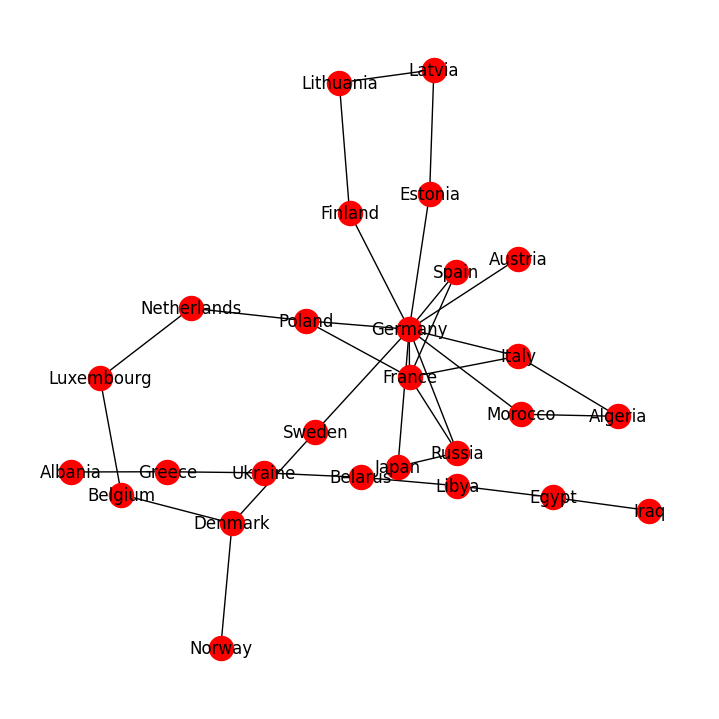

In [7]:
#Network graph using NetworkX & matplotlib
plt.figure(figsize = (7,7))
pos = nx.kamada_kawai_layout(G)  #Stores the result of a calculation step in the dictionary “pos” (position nodes on the space)
nx.draw(G, with_labels = True, node_color = 'red', edge_cmap = plt.cm.Blues, pos = pos)
plt.show() 

##### Graph visualization - Pyvis

In [9]:
#create an empty network object
net = Network()

In [10]:
#add parameters (dimensions, background color, and font color of your graph)
net = Network(notebook = True,width="900px", height="800px", bgcolor='#222222', font_color='white')

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 


In [11]:
#Define nodes from the G object
node_degree = dict(G.degree)

In [12]:
#Set up node size attributes
nx.set_node_attributes(G, node_degree, 'size') #Callthe degree method of the G object, set the node size
net.from_nx(G) #Create a graph based on the G network
net.show_buttons(filter_ = True) #display a set of filter and options for the graph
net.repulsion() #method tackles the physics options of the graph
net.show("countries.html") #display and save the graph

### Community detection - Leiden algorithm

In [14]:
#Import Leiden algorithm in the “cdlib” Python package
from cdlib import algorithms

Note: to be able to use all crisp methods, you need to install some additional packages:  {'graph_tool', 'wurlitzer', 'infomap', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap'}


In [15]:
#Apply the Leiden algorithm (Note: #!pip install python-igraph leidenalg)
communs = algorithms.leiden(G)

In [16]:
type(communs)

cdlib.classes.node_clustering.NodeClustering

In [17]:
#Convert the communs object
new_communs = communs.to_node_community_map()

In [18]:
new_communs

defaultdict(list,
            {'France': [0],
             'Russia': [0],
             'Germany': [0],
             'Italy': [0],
             'Austria': [0],
             'Spain': [0],
             'Poland': [0],
             'Japan': [0],
             'Morocco': [0],
             'Algeria': [0],
             'Albania': [1],
             'Greece': [1],
             'Ukraine': [1],
             'Belarus': [1],
             'Libya': [1],
             'Egypt': [1],
             'Iraq': [1],
             'Netherlands': [2],
             'Luxembourg': [2],
             'Belgium': [2],
             'Denmark': [2],
             'Norway': [2],
             'Sweden': [2],
             'Estonia': [3],
             'Latvia': [3],
             'Lithuania': [3],
             'Finland': [3]})

In [19]:
#Create a dictionary where each entry's value is the first element of the corresponding list  for each key-value pair (k, v) in the new_communs dictionary
##Put the output from new_communs into a dictionary
dict_communs = {k:v[0] for k,v in new_communs.items()} 
#iterates through the nodes in the network until it finds the optimal combination of nodes in each community

In [20]:
dict_communs

{'France': 0,
 'Russia': 0,
 'Germany': 0,
 'Italy': 0,
 'Austria': 0,
 'Spain': 0,
 'Poland': 0,
 'Japan': 0,
 'Morocco': 0,
 'Algeria': 0,
 'Albania': 1,
 'Greece': 1,
 'Ukraine': 1,
 'Belarus': 1,
 'Libya': 1,
 'Egypt': 1,
 'Iraq': 1,
 'Netherlands': 2,
 'Luxembourg': 2,
 'Belgium': 2,
 'Denmark': 2,
 'Norway': 2,
 'Sweden': 2,
 'Estonia': 3,
 'Latvia': 3,
 'Lithuania': 3,
 'Finland': 3}

In [21]:
#Rerun network graph with the communities as an argument
nx.set_node_attributes(G, dict_communs, 'group') #pyvis  read the grouping information in that object and apply it to the graph
communs_net = Network(notebook = True, width="1300px", height="700px", bgcolor='#222222', font_color='white')
communs_net.from_nx(G)
communs_net.show_buttons(filter_ = True)
communs_net.repulsion()
communs_net.show("countries_communities_leiden.html")

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 


## Observations
 
+ The Leiden algorithm separated the countries into four main communities.
+ The significant events of the 20th century not limited to World Wars I and II, the Cold War, the rise of communism, the Great Depression, and the Holocaust, along with technological advancements and societal changes.
+ The countries in blue played a major role in these events. For instance, Germany was significant in various events, including the Fall of the Berlin Wall.
+ The countries in red were involved in these events both directly and indirectly. Some of these countries are related to those involved in blue.
+ The countries in green were associated with different set of events.
+ The countries in orange are linked to an important event from the 20th century. Additionally, countries such as Finland and Estonia were connected to certain events involving Germany.

+ The partition makw sense according to history, while there were many events happning at the smae time involoivng a gorup of counties together, and sometimes a set of coutnies are inviliced in more than one event at the same time.
+  Gemrany palyed a key role in different ievents in the 20th century, along with France and Poland, Japan, and Russia.
+  What's suprising is that there is no role for the UK mentioned in thr 20th century events.

+ The partition makes sense historically, as many events involved groups of countries simultaneously, with some countries participating in multiple events at the same time.
+ Germany played a key role in various events in the 20th century, alongside France, Poland, Japan, and Russia.
+ Surprisingly, the UK and the US are not mentioned in relation to 20th-century events, despite their significant involvement.
+ This highlights that the events predominantly involved many European countries, along with Russia, Japan, Morocco, and Algeria.

### The most important Countries in the 20th Century

#### Degree centrality

In [35]:
#Degree centrality -measures the number of edges attached to a node
degree_dict = nx.degree_centrality(G)

In [36]:
#Check -a dictionary with the output of the calculation from [degree_centrality]
degree_dict

{'France': 0.19230769230769232,
 'Russia': 0.11538461538461539,
 'Germany': 0.42307692307692313,
 'Italy': 0.11538461538461539,
 'Austria': 0.038461538461538464,
 'Spain': 0.07692307692307693,
 'Poland': 0.11538461538461539,
 'Estonia': 0.07692307692307693,
 'Latvia': 0.07692307692307693,
 'Lithuania': 0.07692307692307693,
 'Finland': 0.07692307692307693,
 'Netherlands': 0.07692307692307693,
 'Luxembourg': 0.07692307692307693,
 'Belgium': 0.07692307692307693,
 'Denmark': 0.11538461538461539,
 'Norway': 0.038461538461538464,
 'Sweden': 0.07692307692307693,
 'Albania': 0.038461538461538464,
 'Greece': 0.07692307692307693,
 'Ukraine': 0.07692307692307693,
 'Belarus': 0.07692307692307693,
 'Libya': 0.07692307692307693,
 'Egypt': 0.07692307692307693,
 'Iraq': 0.038461538461538464,
 'Japan': 0.07692307692307693,
 'Morocco': 0.07692307692307693,
 'Algeria': 0.07692307692307693}

In [45]:
#Convert the degree_dict to a pandas dataframe
degree_df = pd.DataFrame(degree_dict.items(), columns=['characters','centrality'])

In [49]:
#Sort the centrality values for bar chart plotting 
degree_df.sort_values(by = ['centrality'], ascending=False, inplace = True)

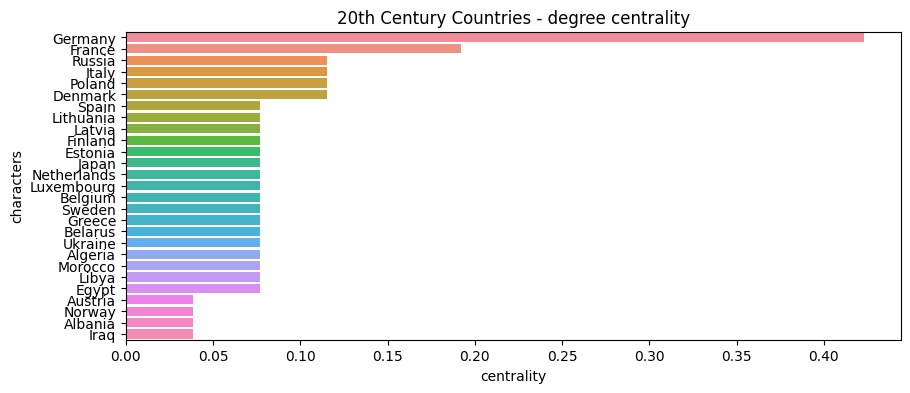

In [51]:
#Plot the degree centrality
plt.figure(figsize = (10, 4))
with sns.dark_palette("xkcd:blue", 22):
    sns.barplot(x = "centrality", y = "characters",
    saturation = 0.9, data = degree_df).set_title("20th Century Countries - degree centrality")

In [53]:
# Save centrality measures
nx.set_node_attributes(G, degree_dict, 'degree_centrality')

## Observations

+ The bar chart indicates that Germany has the highest degree of centrality.
+ Germany has the most connections to other countries in 20th-century events.
+ France follows, unsurprisingly, due to its colonial influence and involvement in various world events at the time.
+ There are four sets of degree centrality, aligning with the interactive graph we observed earlier.

#### Closeness centrality

In [58]:
#Calculate the mean distance from one node to any other node
closeness_dict = nx.closeness_centrality(G)

In [60]:
#Convert the degree_dict to a pandas dataframe
closeness_df = pd.DataFrame(closeness_dict.items(), columns=['characters','centrality'])

In [62]:
#Sort the centrality values for bar chart plotting 
closeness_df.sort_values(by = ['centrality'], ascending=False, inplace = True)

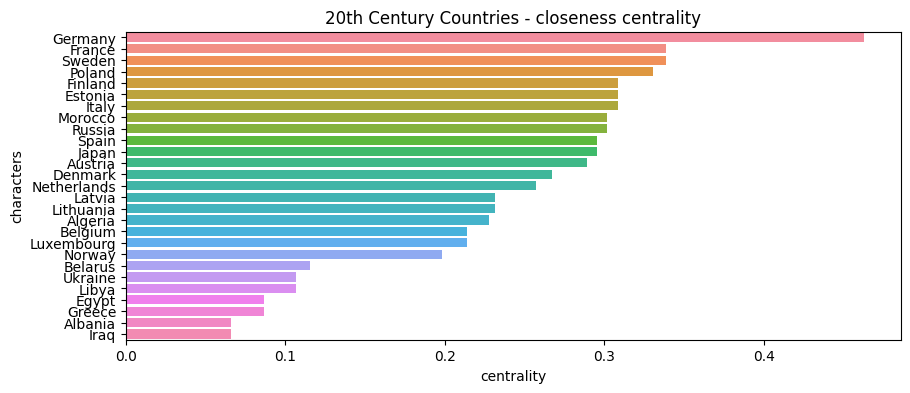

In [64]:
#Plot the Closeness Centrality
plt.figure(figsize = (10, 4))
with sns.dark_palette("xkcd:blue", 22):
    sns.barplot(x = "centrality", y = "characters",
    saturation = 0.9, data = closeness_df).set_title("20th Century Countries - closeness centrality")

In [66]:
# Save centrality measures
nx.set_node_attributes(G, closeness_dict, 'closeness_centrality')

## Observations

+ The order of the countries is similar to what we observed in the degree of centrality.
+ Most countries rank highly on the closeness scale because they are directly or indirectly connected to the main countries, like Germany.
+ However, seven countries at the bottom of the chart rank low on the closeness scale as they are not connected to the main events or countries like Germany.

#### Betweenness centrality

In [70]:
#Measures the number of paths that a node lies on [find nodes that serve as a bridge from one part of a graph to another]
betweenness_dict = nx.betweenness_centrality(G)

In [72]:
#Convert the degree_dict to a pandas dataframe
betweennes_df = pd.DataFrame(betweenness_dict.items(), columns=['characters','centrality'])

In [74]:
#Sort the centrality values for bar chart plotting 
betweennes_df.sort_values(by = ['centrality'], ascending=False, inplace = True)

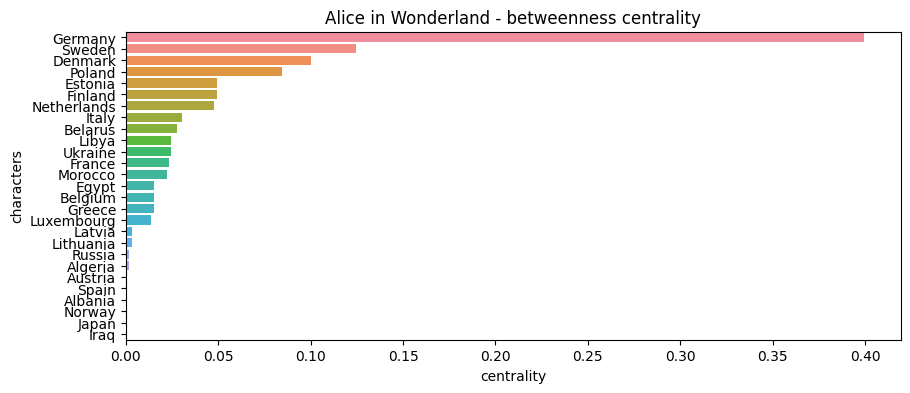

In [76]:
#Plot the Betweenness Centrality
plt.figure(figsize = (10, 4))
with sns.dark_palette("xkcd:blue", 22):
    sns.barplot(x = "centrality", y = "characters",
    saturation = 0.9, data = betweennes_df).set_title("Alice in Wonderland - betweenness centrality")

In [78]:
# Save centrality measures
nx.set_node_attributes(G, betweenness_dict, 'betweenness_centrality')

## Observations

+ The betweenness measure confirms the closeness centrality score, indicating that Germany is the most "influential" country, followed by Sweden.
+ All other countries score relatively low, which is unsurprising, as they were either involved in smaller events or not connected to the major countries involved in significant 20th-century events.